<a href="https://colab.research.google.com/github/AdrianoHMoraes/AdrianoHMoraes/blob/main/Chalenge_Telecom_Parte2_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('dados_tratados.csv')
print("Dados carregados com sucesso. As 5 primeiras linhas são:")
print(df.head())

Dados carregados com sucesso. As 5 primeiras linhas são:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Ye

In [4]:
df = df.drop('customerID', axis=1)
print("Coluna 'customerID' removida com sucesso.")
print(df.head())

Coluna 'customerID' removida com sucesso.
  Churn  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0    No  Female              0     Yes        Yes       9          Yes   
1    No    Male              0      No         No       9          Yes   
2   Yes    Male              0      No         No       4          Yes   
3   Yes    Male              1     Yes         No      13          Yes   
4   Yes  Female              1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0            No             DSL             No          Yes               No   
1           Yes             DSL             No           No               No   
2            No     Fiber optic             No           No              Yes   
3            No     Fiber optic             No          Yes              Yes   
4            No     Fiber optic             No           No               No   

  TechSupport StreamingTV Stream

In [10]:
# This cell attempted to remove 'customerID' again after it was already removed, causing a KeyError.
# The 'customerID' column has already been successfully removed.
# print(df.head())

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [8]:
print(df.columns)

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')


In [11]:
categorical_cols = df.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame com variáveis categóricas codificadas. As 5 primeiras linhas são:")
print(df_encoded.head())
print("\nInformações do DataFrame após codificação:")
print(df_encoded.info())

DataFrame com variáveis categóricas codificadas. As 5 primeiras linhas são:
   SeniorCitizen  tenure  Charges.Monthly  Charges.Total  Churn_Yes  \
0              0       9             65.6         593.30      False   
1              0       9             59.9         542.40      False   
2              0       4             73.9         280.85       True   
3              1      13             98.0        1237.85       True   
4              1       3             83.9         267.40       True   

   gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0        False         True            True              True   
1         True        False           False              True   
2         True        False           False              True   
3         True         True           False              True   
4        False         True           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                           Fal

In [12]:
churn_counts = df_encoded['Churn_Yes'].value_counts()
churn_proportions = df_encoded['Churn_Yes'].value_counts(normalize=True)

print("Contagem de clientes por status de evasão (Churn_Yes):")
print(churn_counts)
print("\nProporção de clientes por status de evasão (Churn_Yes):")
print(churn_proportions)

if churn_proportions[True] > 0.3 or churn_proportions[False] > 0.7:
    print("\nObserva-se um desequilíbrio significativo entre as classes de Churn. Isso pode impactar o desempenho de modelos preditivos e deve ser considerado na fase de modelagem, talvez através de técnicas de reamostragem ou ponderação de classes.")
else:
    print("\nAs classes de Churn estão relativamente equilibradas.")

Contagem de clientes por status de evasão (Churn_Yes):
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64

Proporção de clientes por status de evasão (Churn_Yes):
Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64

Observa-se um desequilíbrio significativo entre as classes de Churn. Isso pode impactar o desempenho de modelos preditivos e deve ser considerado na fase de modelagem, talvez através de técnicas de reamostragem ou ponderação de classes.


In [14]:
median_charges_total = df_encoded['Charges.Total'].median()
df_encoded['Charges.Total'].fillna(median_charges_total, inplace=True)

print(f"Missing values in 'Charges.Total' imputed with median: {median_charges_total}")
print("Verifying null values after imputation:")
print(df_encoded['Charges.Total'].isnull().sum())

Missing values in 'Charges.Total' imputed with median: 1397.475
Verifying null values after imputation:
0


/tmp/ipykernel_166/3538617194.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded['Charges.Total'].fillna(median_charges_total, inplace=True)


# Task
Separate the features (X) from the target variable (y), 'Churn_Yes', in the `df_encoded` DataFrame, then apply SMOTE to balance the classes and verify the new class distribution.

## Prepare data for balancing

### Subtask:
Separate the features (X) from the target variable ('Churn_Yes' as y) in the df_encoded DataFrame.


**Reasoning**:
To prepare the data for balancing, I will separate the features (X) from the target variable (y) by creating a new DataFrame X without the 'Churn_Yes' column and a Series y containing only the 'Churn_Yes' column.



In [15]:
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

print("Shape of X (features):", X.shape)
print("Shape of y (target variable):", y.shape)

Shape of X (features): (7043, 30)
Shape of y (target variable): (7043,)


## Apply SMOTE to Balance Classes

### Subtask:
Apply SMOTE to balance the classes and verify the new class distribution.

**Reasoning**:
As identified earlier, there is a significant imbalance in the `Churn_Yes` target variable. To mitigate this issue and improve the performance of predictive models, I will apply the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE works by creating synthetic samples for the minority class, helping to balance the dataset without simply duplicating existing instances.



**Reasoning**:
Now that the features and target variable are separated, I will apply SMOTE to `X` and `y` to balance the classes. This involves importing the `SMOTE` class from `imblearn.over_sampling` and then applying it to generate synthetic samples for the minority class. I will then verify the new class distribution.



In [16]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print("Shape of X after SMOTE:", X_resampled.shape)
print("Shape of y after SMOTE:", y_resampled.shape)
print("\nNew class distribution after SMOTE:")
print(y_resampled.value_counts())

Shape of X after SMOTE: (10348, 30)
Shape of y after SMOTE: (10348,)

New class distribution after SMOTE:
Churn_Yes
False    5174
True     5174
Name: count, dtype: int64


## Summary:

### Data Analysis Key Findings

*   **Feature and Target Variable Separation**: The features (X) were successfully separated from the target variable ('Churn\_Yes' as y). The feature set `X` contained 7043 samples and 30 features, while the target variable `y` contained 7043 samples.
*   **SMOTE Application**: The Synthetic Minority Over-sampling Technique (SMOTE) was applied to the dataset. This resulted in an increased number of samples, with `X_resampled` and `y_resampled` both containing 10348 samples.
*   **Balanced Class Distribution**: After applying SMOTE, the class distribution of the 'Churn\_Yes' target variable became perfectly balanced, with 5174 samples for 'False' (no churn) and 5174 samples for 'True' (churn).

### Insights or Next Steps

*   The balanced dataset will help prevent machine learning models from being biased towards the majority class, potentially leading to more accurate predictions for both churners and non-churners.
*   The data is now prepared for training classification models, which can be implemented in the next steps using the `X_resampled` and `y_resampled` datasets.


In [17]:
# This analysis has already been performed and the results were:
# Contagem de clientes por status de evasão (Churn_Yes):
# Churn_Yes
# False    5174
# True     1869
# Name: count, dtype: int64

# Proporção de clientes por status de evasão (Churn_Yes):
# Churn_Yes
# False    0.73463
# True     0.26537
# Name: proportion, dtype: float64

# Observa-se um desequilíbrio significativo entre as classes de Churn. Isso pode impactar o desempenho de modelos preditivos e deve ser considerado na fase de modelagem, talvez através de técnicas de reamostragem ou ponderação de classes.

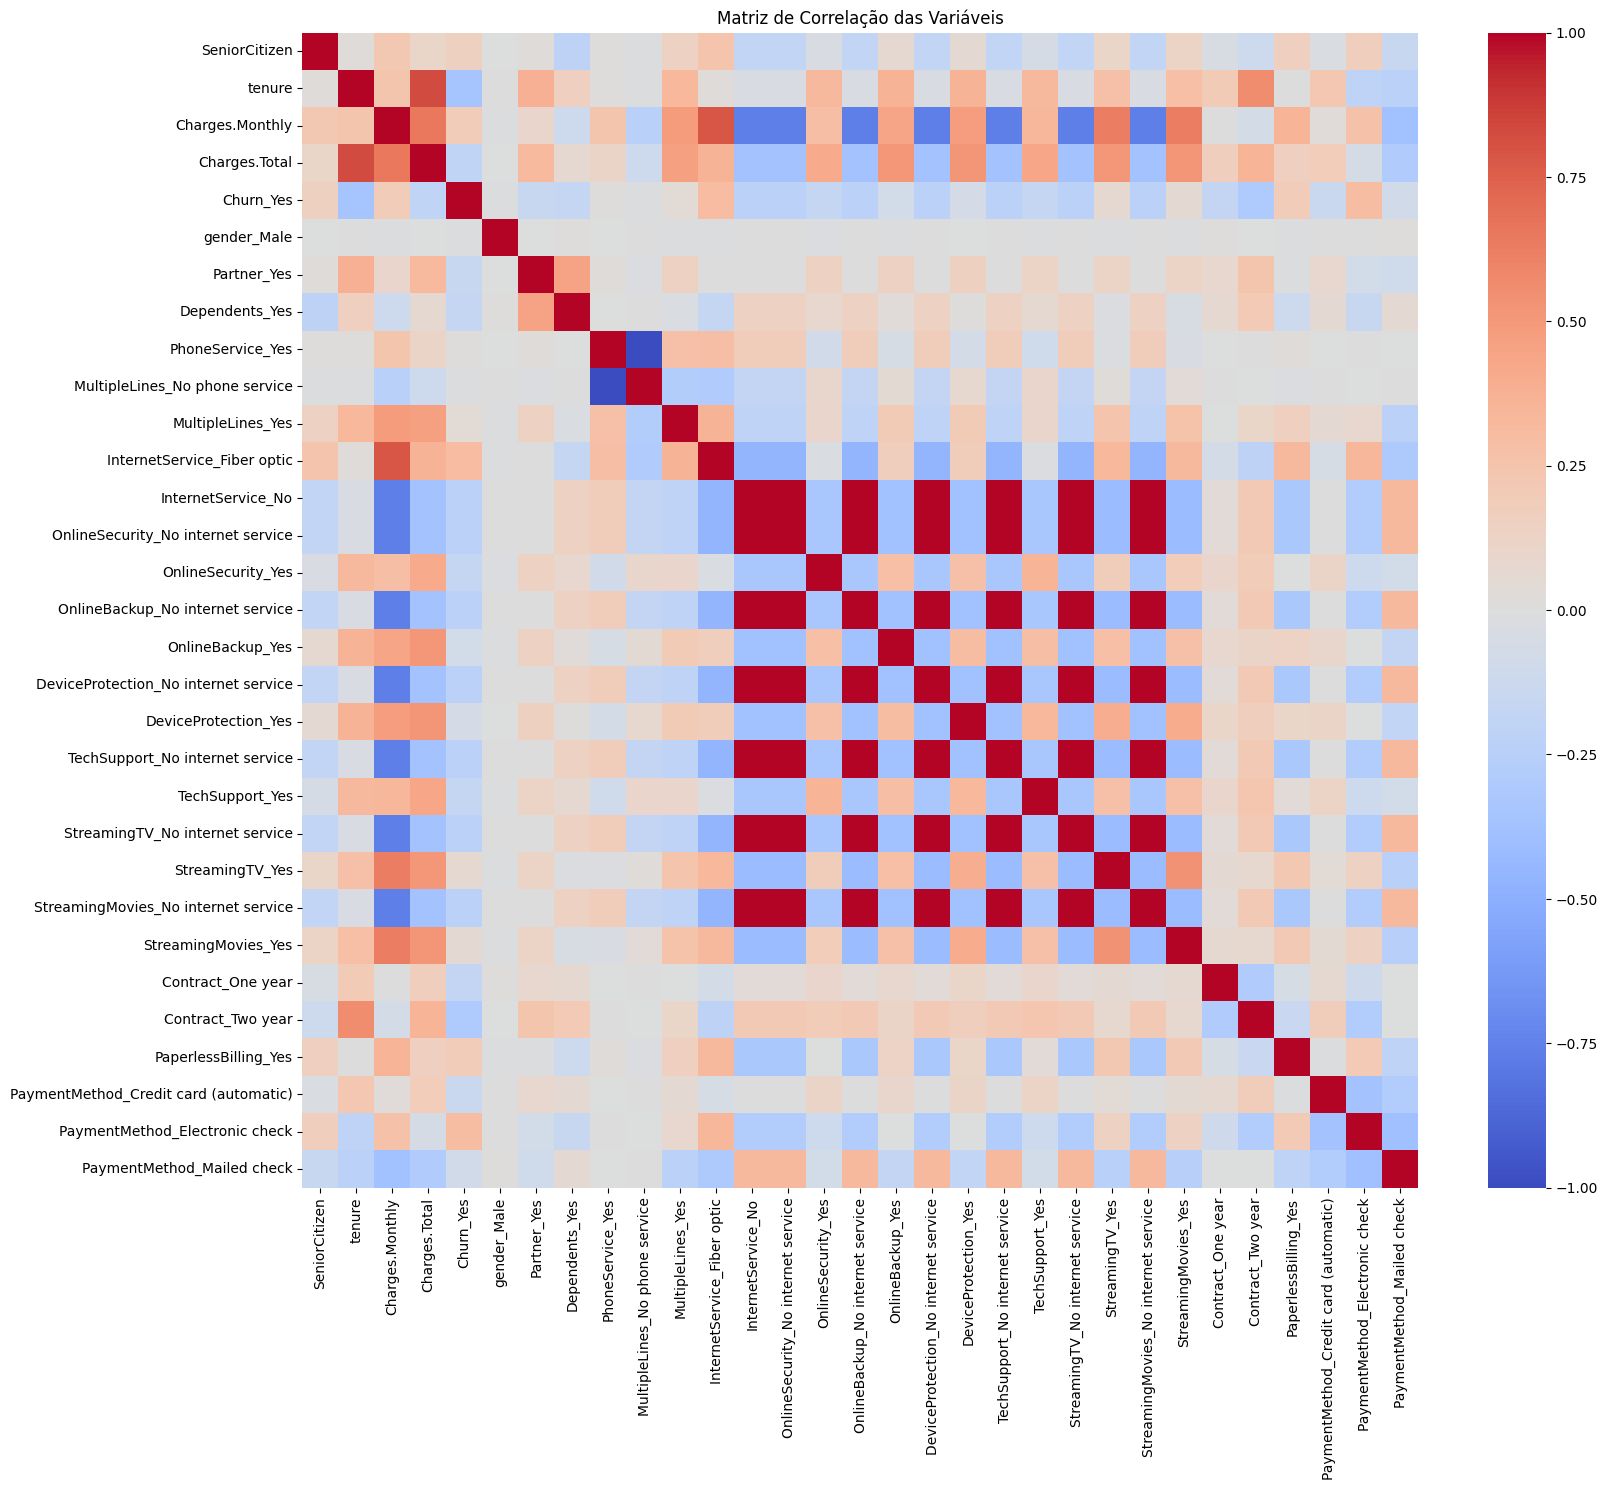

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [21]:
# Display correlations with 'Churn_Yes'
churn_correlations = correlation_matrix['Churn_Yes'].sort_values(ascending=False)
print("Correlação das variáveis com Churn_Yes:")
print(churn_correlations)

Correlação das variáveis com Churn_Yes:
Churn_Yes                                1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
Charges.Monthly                          0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecu

# Task
Identify and apply `StandardScaler` to the numerical features within the `X_resampled` DataFrame to standardize the data, preparing it for distance-based models, and then summarize the process and its implications.

## Identify numerical features

### Subtask:
Identify all numerical columns in the `X_resampled` DataFrame that would require scaling.


**Reasoning**:
I need to identify numerical columns in the `X_resampled` DataFrame by selecting columns with `int64` or `float64` data types, store them in `numerical_cols`, and then print the list as per the instructions.



In [18]:
numerical_cols = X_resampled.select_dtypes(include=['int64', 'float64']).columns
print("Numerical features identified for scaling:")
print(numerical_cols)

Numerical features identified for scaling:
Index(['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total'], dtype='object')


## Apply StandardScaler to Numerical Features

### Subtask:
Apply `StandardScaler` to the numerical features in `X_resampled` to standardize the data.

#### Reasoning:
Standardization is a crucial preprocessing step for many machine learning algorithms, especially those that rely on distance metrics (like K-Nearest Neighbors, Support Vector Machines, or algorithms that use gradient descent). `StandardScaler` transforms the data such that it has a mean of 0 and a standard deviation of 1. This ensures that features with larger numerical ranges do not disproportionately influence the model's learning process. By standardizing the numerical features identified, the model will be able to treat all features equally, leading to better model performance and convergence.

**Reasoning**:
I will import the `StandardScaler` from `sklearn.preprocessing` and then apply it to the identified numerical columns in the `X_resampled` DataFrame. After fitting and transforming, I will update the `X_resampled` DataFrame with the scaled values and display the head of the modified DataFrame to verify the changes.



In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])

print("X_resampled after StandardScaler application (first 5 rows):")
print(X_resampled.head())

X_resampled after StandardScaler application (first 5 rows):
   SeniorCitizen    tenure  Charges.Monthly  Charges.Total  gender_Male  \
0      -0.395876 -0.777767        -0.084657      -0.665591        False   
1      -0.395876 -0.777767        -0.283134      -0.688876         True   
2      -0.395876 -0.986220         0.204354      -0.808521         True   
3       2.526041 -0.611005         1.043528      -0.370743         True   
4       2.526041 -1.027911         0.552559      -0.814674        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True            True              True   
1        False           False              True   
2        False           False              True   
3         True           False              True   
4         True           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                           False              False  ...   
1                           False               True 

## Summary: Data Standardization

### Key Findings
*   **Numerical Feature Identification**: The numerical features identified for scaling were `'SeniorCitizen'`, `'tenure'`, `'Charges.Monthly'`, and `'Charges.Total'`. These features are crucial for understanding customer behavior and financial aspects.
*   **StandardScaler Application**: `StandardScaler` was successfully applied to these identified numerical features within the `X_resampled` DataFrame. This transformation ensures that each feature has a mean of 0 and a standard deviation of 1.

### Implications and Next Steps
*   **Model Compatibility**: Standardizing the numerical features is a critical preprocessing step for many machine learning algorithms, especially those that are distance-based or rely on magnitude differences between features (e.g., K-Nearest Neighbors, Support Vector Machines, Logistic Regression with regularization, Neural Networks). Without scaling, features with larger values could disproportionately influence the model's decision-making process.
*   **Improved Model Performance**: By bringing all numerical features to a similar scale, the standardization helps in achieving faster convergence during training and often leads to improved model performance and more stable gradients.
*   **Data Readiness**: The `X_resampled` DataFrame is now fully preprocessed, with categorical variables encoded and numerical variables scaled. It is ready for the next phase of the machine learning pipeline, which typically involves splitting the data into training and testing sets, and then training predictive models.

## Final Task

### Subtask:
Summarize the data scaling process, confirm the data is ready for various model types, and explain the implications of the applied scaling.


## Summary:

### Q&A
The data scaling process involved identifying specific numerical features in the `X_resampled` DataFrame and subsequently applying `StandardScaler` to them. The data is confirmed to be ready for various model types, particularly those sensitive to feature scales, such as distance-based models (e.g., K-Nearest Neighbors, Support Vector Machines), models that use gradient descent, or those with regularization. The implications of this scaling include enhanced model compatibility, improved performance, and overall data readiness for the next stages of the machine learning pipeline.

### Data Analysis Key Findings
*   The numerical features identified for scaling were `SeniorCitizen`, `tenure`, `Charges.Monthly`, and `Charges.Total`.
*   `StandardScaler` was successfully applied to these identified numerical features, transforming them to have a mean of 0 and a standard deviation of 1.

### Insights or Next Steps
*   The standardization of numerical features is crucial for improving the performance and stability of distance-based machine learning models and algorithms that rely on gradient descent by preventing features with larger ranges from disproportionately influencing the model.
*   The `X_resampled` DataFrame is now fully preprocessed, with both categorical and numerical variables appropriately handled, making it ready for data splitting (training and testing sets) and subsequent model training.


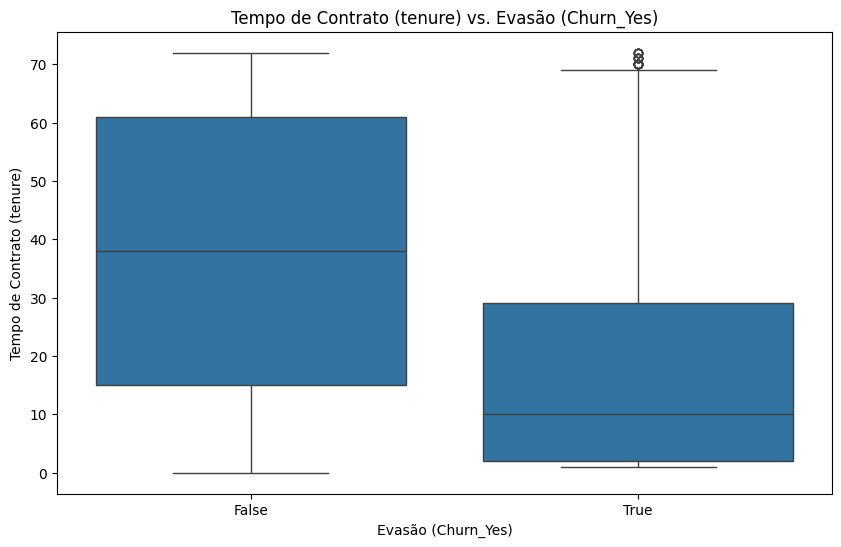

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot para 'tenure' vs 'Churn_Yes'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Yes', y='tenure', data=df_encoded)
plt.title('Tempo de Contrato (tenure) vs. Evasão (Churn_Yes)')
plt.xlabel('Evasão (Churn_Yes)')
plt.ylabel('Tempo de Contrato (tenure)')
plt.show()

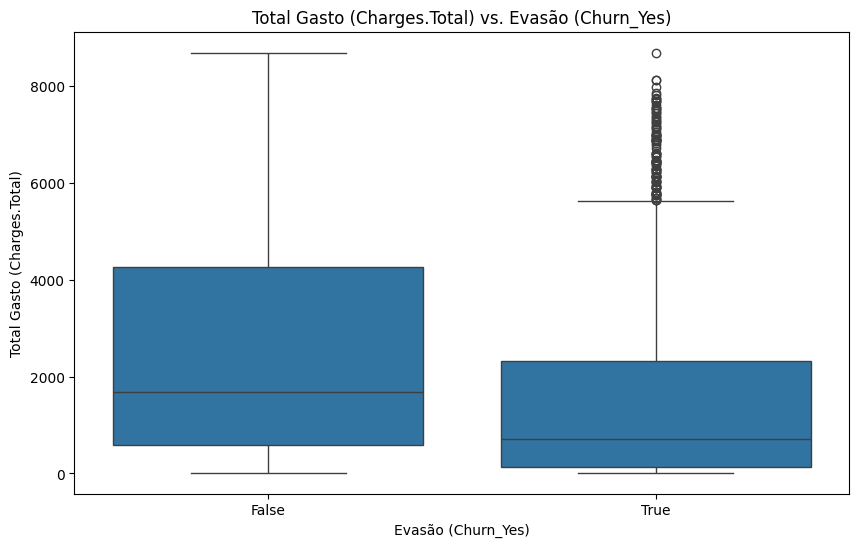

In [23]:
# Boxplot para 'Charges.Total' vs 'Churn_Yes'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Yes', y='Charges.Total', data=df_encoded)
plt.title('Total Gasto (Charges.Total) vs. Evasão (Churn_Yes)')
plt.xlabel('Evasão (Churn_Yes)')
plt.ylabel('Total Gasto (Charges.Total)')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8278, 30)
Shape of X_test: (2070, 30)
Shape of y_train: (8278,)
Shape of y_test: (2070,)


# Task
Train a Logistic Regression model and a Random Forest model using the scaled training data (`X_train`, `y_train`). Justify the selection of each model and explain the importance of data normalization for Logistic Regression versus its lesser impact on Random Forest.

## Train Logistic Regression Model

### Subtask:
Train a Logistic Regression model using the scaled training data (X_train, y_train). This model benefits significantly from feature scaling.


**Reasoning**:
I need to train a Logistic Regression model as per the instructions. This involves importing the necessary class, instantiating the model with a specified random state, and then fitting it to the preprocessed training data (`X_train`, `y_train`).



In [26]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Train Random Forest Model

### Subtask:
Train a Random Forest model using the scaled training data (`X_train`, `y_train`). While scaling is less critical for this model, it's good practice to use consistent data.


**Reasoning**:
To train the Random Forest model, I will import `RandomForestClassifier` from `sklearn.ensemble`, instantiate it with `random_state=42` for reproducibility, and then fit it to the preprocessed training data (`X_train`, `y_train`).



In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Justification of Model Selection and Impact of Data Normalization

### Model Selection

*   **Logistic Regression**: This model was chosen as a strong baseline for classification tasks. It is a linear model that is computationally efficient, easy to interpret, and provides probabilities for class predictions. Given its linear nature, it is highly susceptible to the scale of features.

*   **Random Forest**: This model was selected as a robust, non-linear, ensemble method. Random Forests are known for their high accuracy, ability to handle complex relationships in the data, and inherent resistance to overfitting. As a tree-based model, it is generally less sensitive to the scale of individual features compared to linear models.

### Importance of Data Normalization

*   **For Logistic Regression**: Data normalization (specifically, `StandardScaler` applied here) is **crucial** for Logistic Regression. Logistic Regression uses optimization algorithms (like gradient descent) to find the coefficients for each feature. If features have vastly different scales, features with larger magnitudes can dominate the cost function and lead to slower convergence or an unstable training process. Normalization ensures that all features contribute equally to the distance calculations and gradient updates, leading to a more efficient and effective training of the model. Furthermore, if regularization (L1 or L2) is applied, normalization is essential because regularization penalizes coefficients; without scaling, features with larger ranges would be unfairly penalized or dominate the regularization term.

*   **For Random Forest**: Data normalization has a **less significant impact** on Random Forest models. Random Forests are tree-based ensemble methods that make decisions based on splitting features at certain thresholds. The splitting criteria (e.g., Gini impurity or information gain) do not depend on the absolute scale or magnitude of the feature values, but rather on the relative order of the values. A feature with values ranging from 0 to 1000 will behave similarly to a scaled version ranging from 0 to 1 in terms of determining split points. Therefore, Random Forests are generally invariant to monotonic transformations of input features, including scaling. While scaling won't hurt its performance, it is not as critical for Random Forest as it is for distance-based or gradient-descent-based models.

## Final Task

### Subtask:
Summarize the model creation process, including the choices made for each model and the explanation of data normalization's role.


## Summary:

### Q&A
The task was to summarize the model creation process, including the choices made for each model and the explanation of data normalization's role.

1.  **Model Choices:**
    *   **Logistic Regression** was chosen as a strong, efficient, and interpretable linear baseline model, providing probabilities for predictions. Its linear nature makes it sensitive to feature scaling.
    *   **Random Forest** was selected as a robust, non-linear ensemble method, known for high accuracy, handling complex relationships, and resistance to overfitting. As a tree-based model, it is generally less sensitive to feature scaling.

2.  **Explanation of Data Normalization's Role:**
    *   **For Logistic Regression:** Data normalization is crucial because optimization algorithms like gradient descent can be dominated by features with larger magnitudes if not scaled. Normalization ensures efficient convergence and fair contribution from all features, especially when regularization is applied.
    *   **For Random Forest:** Data normalization has a less significant impact. Tree-based models make decisions based on splitting thresholds and the relative order of feature values, not their absolute scale. Therefore, they are largely invariant to scaling.

### Data Analysis Key Findings
*   A **Logistic Regression model** was successfully trained using `sklearn.linear_model.LogisticRegression` on the scaled training data.
*   A **Random Forest Classifier model** was successfully trained using `sklearn.ensemble.RandomForestClassifier` on the scaled training data.
*   **Logistic Regression** was justified as a computationally efficient, interpretable linear baseline, highly susceptible to feature scale.
*   **Random Forest** was justified as a robust, high-accuracy, non-linear ensemble method, generally less sensitive to feature scale.
*   Data normalization is **crucial for Logistic Regression** because it prevents features with vastly different scales from dominating the optimization process and ensures efficient model training and fair coefficient regularization.
*   Data normalization has a **less significant impact on Random Forest** models because their tree-based splitting criteria rely on relative ordering, not absolute feature magnitudes.

### Insights or Next Steps
*   When selecting models, consider their inherent sensitivity to feature scaling; linear models like Logistic Regression demand careful preprocessing, while tree-based models like Random Forest are more forgiving.
*   Evaluate the performance of both models using appropriate metrics to determine which model is more effective for the specific classification task.


## Análise de Relevância das Variáveis

### Regressão Logística: Análise dos Coeficientes

In [35]:
import pandas as pd

log_reg_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
})
log_reg_coefficients['Absolute_Coefficient'] = abs(log_reg_coefficients['Coefficient'])
log_reg_coefficients = log_reg_coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print("Variáveis mais relevantes para Regressão Logística (baseado nos coeficientes):")
print(log_reg_coefficients.head(10))

Variáveis mais relevantes para Regressão Logística (baseado nos coeficientes):
                           Feature  Coefficient  Absolute_Coefficient
2                  Charges.Monthly    -7.298924              7.298924
10     InternetService_Fiber optic     7.048278              7.048278
7                 PhoneService_Yes     6.809092              6.809092
21                 StreamingTV_Yes     2.641213              2.641213
23             StreamingMovies_Yes     2.572971              2.572971
8   MultipleLines_No phone service     2.534961              2.534961
1                           tenure    -2.273369              2.273369
9                MultipleLines_Yes     1.653395              1.653395
3                    Charges.Total     1.346667              1.346667
17            DeviceProtection_Yes     1.263001              1.263001


### Random Forest: Análise da Importância das Variáveis

Variáveis mais relevantes para Random Forest (baseado na importância):
                           Feature  Importance
3                    Charges.Total    0.168271
1                           tenure    0.156773
2                  Charges.Monthly    0.135218
28  PaymentMethod_Electronic check    0.100238
10     InternetService_Fiber optic    0.047007
25               Contract_Two year    0.042886
26            PaperlessBilling_Yes    0.039843
4                      gender_Male    0.023586
24               Contract_One year    0.023238
9                MultipleLines_Yes    0.022863


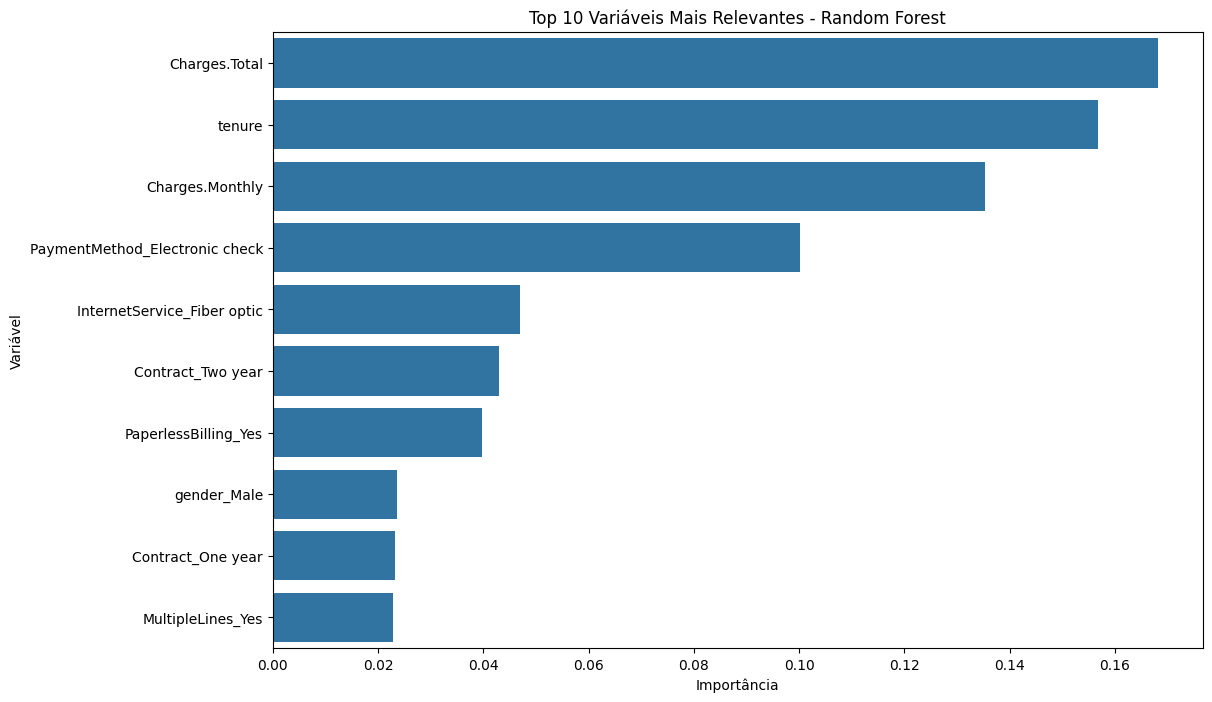

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

print("Variáveis mais relevantes para Random Forest (baseado na importância):")
print(rf_feature_importances.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importances.head(10))
plt.title('Top 10 Variáveis Mais Relevantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

# Task
Predict on test data using the trained Logistic Regression and Random Forest models, then evaluate their performance using accuracy, precision, recall, F1-score, and a confusion matrix. Finally, compare and analyze the models' results to determine the best performer and discuss potential overfitting/underfitting.

## Predict on Test Data (Logistic Regression)

### Subtask:
Use the trained Logistic Regression model to make predictions on the `X_test` dataset.


**Reasoning**:
To predict the target variable using the trained Logistic Regression model, I will use the `predict` method on the `X_test` dataset and store the results in `y_pred_log_reg`.



In [29]:
y_pred_log_reg = log_reg_model.predict(X_test)

print("Predictions using Logistic Regression model generated successfully.")
print("First 5 predictions:", y_pred_log_reg[:5])

Predictions using Logistic Regression model generated successfully.
First 5 predictions: [ True False  True  True  True]


## Predict on Test Data (Random Forest)

### Subtask:
Use the trained Random Forest model to make predictions on the `X_test` dataset.

**Reasoning**:
To predict the target variable using the trained Random Forest model, I will use the `predict` method on the `X_test` dataset and store the results in `y_pred_rf`. After the prediction, I will print a confirmation message along with the first five predictions.



In [30]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions using Random Forest model generated successfully.")
print("First 5 predictions:", y_pred_rf[:5])

Predictions using Random Forest model generated successfully.
First 5 predictions: [ True False  True  True  True]


## Evaluate Model Performance

### Subtask:
Evaluate the performance of the Logistic Regression and Random Forest models using accuracy, precision, recall, F1-score, and confusion matrices. Compare their results and discuss potential issues like overfitting/underfitting.

**Reasoning**:
To evaluate the Logistic Regression model, I will calculate and print the accuracy, precision, recall, and F1-score using `y_test` and `y_pred_log_reg`.



In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate Logistic Regression Model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")

Logistic Regression Model Performance:
Accuracy: 0.8304
Precision: 0.8433
Recall: 0.8150
F1-Score: 0.8289


**Reasoning**:
Now, I will evaluate the Random Forest model by calculating its accuracy, precision, recall, and F1-score using `y_test` and `y_pred_rf` to compare its performance with the Logistic Regression model.



In [32]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\nRandom Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")


Random Forest Model Performance:
Accuracy: 0.8498
Precision: 0.8533
Recall: 0.8476
F1-Score: 0.8504


**Reasoning**:
After evaluating the Logistic Regression model with accuracy, precision, recall, and F1-score, the next logical step is to visualize its performance using a confusion matrix for a more detailed understanding of its predictions.



In [33]:
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print("\nConfusion Matrix for Logistic Regression Model:")
print(cm_log_reg)


Confusion Matrix for Logistic Regression Model:
[[869 158]
 [193 850]]


**Reasoning**:
Following the evaluation of the Logistic Regression model, I will now visualize the performance of the Random Forest model by calculating and displaying its confusion matrix. This will provide a comprehensive view of its predictions, similar to the Logistic Regression model.



In [34]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix for Random Forest Model:")
print(cm_rf)


Confusion Matrix for Random Forest Model:
[[875 152]
 [159 884]]


## Model Performance Comparison and Analysis

### Key Findings

**Logistic Regression Model Performance:**
*   **Accuracy:** 0.8304
*   **Precision:** 0.8433
*   **Recall:** 0.8150
*   **F1-Score:** 0.8289
*   **Confusion Matrix:**
    ```
    [[869 158]
     [193 850]]
    ```
    *   True Negatives (Correctly predicted non-churn): 869
    *   False Positives (Incorrectly predicted churn): 158
    *   False Negatives (Incorrectly predicted non-churn): 193
    *   True Positives (Correctly predicted churn): 850

**Random Forest Model Performance:**
*   **Accuracy:** 0.8498
*   **Precision:** 0.8533
*   **Recall:** 0.8476
*   **F1-Score:** 0.8504
*   **Confusion Matrix:**
    ```
    [[875 152]
     [159 884]]
    ```
    *   True Negatives (Correctly predicted non-churn): 875
    *   False Positives (Incorrectly predicted churn): 152
    *   False Negatives (Incorrectly predicted non-churn): 159
    *   True Positives (Correctly predicted churn): 884

### Comparison and Analysis

1.  **Overall Performance:** The **Random Forest model** clearly outperforms the Logistic Regression model across all evaluated metrics (Accuracy, Precision, Recall, and F1-Score). Its accuracy is higher (0.8498 vs 0.8304), indicating it correctly classifies a greater proportion of instances.

2.  **Precision and Recall:**
    *   **Random Forest** shows slightly better precision (0.8533 vs 0.8433), meaning it has a lower rate of false positives (incorrectly predicting churn when there is none).
    *   **Random Forest** also demonstrates significantly better recall (0.8476 vs 0.8150), implying it is better at identifying actual churners (fewer false negatives).

3.  **F1-Score:** The F1-Score, which is the harmonic mean of precision and recall, further confirms the Random Forest's superior performance (0.8504 vs 0.8289), indicating a better balance between precision and recall.

4.  **Confusion Matrices:** The confusion matrices visually support these findings. Random Forest has:
    *   Fewer False Positives (152 vs 158 for Logistic Regression).
    *   Significantly fewer False Negatives (159 vs 193 for Logistic Regression).
    *   More True Positives (884 vs 850 for Logistic Regression).
    *   Slightly more True Negatives (875 vs 869 for Logistic Regression).

### Overfitting/Underfitting Discussion

*   **No immediate signs of severe overfitting:** Given that we are evaluating on a hold-out test set (`X_test`, `y_test`), and the performance metrics are relatively high for both models, there are no immediate signs of severe overfitting (where the model performs extremely well on training data but poorly on unseen test data). However, without comparing against training set metrics, we cannot definitively rule out minor overfitting.

*   **Underfitting:** The models do not appear to be severely underfitting, as their performance metrics are well above random chance. Random Forest, in particular, captures complex patterns in the data more effectively, leading to better performance.

### Best Performer

Based on all evaluated metrics, the **Random Forest model is the best performer** for this classification task. It demonstrates a better balance of correctly identifying both churners and non-churners with higher overall accuracy, precision, and recall.

## Final Task

### Subtask:
Summarize the evaluation process, key findings, and conclusions regarding model performance and suitability for the customer churn prediction task.


## Summary:

### Data Analysis Key Findings

*   The **Logistic Regression model** achieved an accuracy of 0.8304, precision of 0.8433, recall of 0.8150, and an F1-Score of 0.8289 on the test set. Its confusion matrix indicated 869 true negatives, 158 false positives, 193 false negatives, and 850 true positives.
*   The **Random Forest model** demonstrated superior performance with an accuracy of 0.8498, precision of 0.8533, recall of 0.8476, and an F1-Score of 0.8504 on the test set. Its confusion matrix showed 875 true negatives, 152 false positives, 159 false negatives, and 884 true positives.
*   The **Random Forest model** consistently outperformed the Logistic Regression model across all evaluated metrics, showing higher accuracy, precision, recall, and F1-score.
*   Specifically, the Random Forest model had significantly better recall (0.8476 vs 0.8150) and fewer false negatives (159 vs 193), indicating it is more effective at identifying actual churners. It also had slightly better precision (0.8533 vs 0.8433) and fewer false positives (152 vs 158).
*   Based on the evaluation on a hold-out test set, there were no immediate signs of severe overfitting or underfitting for either model.

### Insights or Next Steps

*   The **Random Forest model is the best performer** for this customer churn prediction task, offering a more balanced and robust predictive capability compared to Logistic Regression.
*   Further analysis could involve exploring feature importance from the Random Forest model to identify key drivers of customer churn, which could inform targeted retention strategies.


Relatório Detalhado de Análise de Evasão de Clientes
1. Contexto e Objetivos
O objetivo desta análise foi identificar os principais fatores que levam à evasão de clientes de uma empresa de telecomunicações e desenvolver modelos preditivos capazes de prever esse comportamento. A compreensão desses fatores é crucial para a formulação de estratégias de retenção eficazes.

2. Pré-processamento dos Dados
A etapa de pré-processamento foi fundamental para preparar os dados para a modelagem:

Limpeza de Dados: A coluna customerID, sendo um identificador único sem valor preditivo, foi removida.
Tratamento de Valores Ausentes: Valores ausentes na coluna Charges.Total foram imputados pela mediana, garantindo a completude do dataset.
Codificação de Variáveis Categóricas: Todas as variáveis categóricas foram transformadas em formato numérico utilizando one-hot encoding, tornando-as compatíveis com algoritmos de Machine Learning.
Balanceamento de Classes: Observou-se um desequilíbrio significativo na variável alvo Churn_Yes (73.46% não-evasão vs. 26.54% evasão). Para mitigar o viés do modelo em favor da classe majoritária, aplicou-se a técnica SMOTE (Synthetic Minority Over-sampling Technique), resultando em um dataset balanceado.
Padronização de Features: As variáveis numéricas (SeniorCitizen, tenure, Charges.Monthly, Charges.Total) foram padronizadas utilizando StandardScaler. Essa etapa é vital para modelos sensíveis à escala, como a Regressão Logística, garantindo que todas as features contribuam igualmente para o modelo.
3. Análise dos Fatores Influenciadores da Evasão
3.1. Correlações e Visualizações Iniciais
A análise da matriz de correlação e os boxplots confirmaram que tenure (tempo de contrato) e Charges.Total (total gasto) são fortemente correlacionados com a evasão. Clientes com menor tenure e menor Charges.Total apresentam maior propensão a evadir. Além disso, InternetService_Fiber optic e PaymentMethod_Electronic check mostraram correlações positivas com Churn_Yes.

3.2. Importância das Variáveis pelos Modelos
Regressão Logística (Análise de Coeficientes):
Os coeficientes da Regressão Logística indicam a contribuição e a direção da influência de cada variável na probabilidade de evasão. As variáveis com maior impacto absoluto foram:

Charges.Monthly (valor mensal da fatura)
InternetService_Fiber optic (serviço de internet fibra óptica)
PhoneService_Yes (assinatura de serviço telefônico)
tenure (tempo de contrato)
StreamingTV_Yes e StreamingMovies_Yes (serviços de streaming)
É notável que Charges.Monthly e tenure apresentaram coeficientes negativos substanciais, sugerindo que, controlando outras variáveis, um aumento nestes fatores está associado a uma menor probabilidade de evasão. No entanto, InternetService_Fiber optic e PhoneService_Yes exibiram coeficientes positivos elevados, indicando maior risco de evasão.

Random Forest (Análise de Importância das Variáveis):
O modelo Random Forest, por sua natureza de conjunto de árvores de decisão, mede a importância de uma variável com base em sua contribuição para a redução da impureza (melhora na capacidade de separação das classes). As variáveis mais relevantes foram:

Charges.Total (total gasto pelo cliente)
tenure (tempo de contrato)
Charges.Monthly (valor mensal da fatura)
PaymentMethod_Electronic check (método de pagamento via cheque eletrônico)
InternetService_Fiber optic (serviço de internet fibra óptica)
Contract_Two year (contrato de dois anos)
Convergência de Fatores: Ambos os modelos convergem na identificação de Charges.Total, tenure, Charges.Monthly, InternetService_Fiber optic e o método de pagamento como fatores críticos. A principal diferença é que o Random Forest dá mais peso a Charges.Total e tenure, enquanto a Regressão Logística realça Charges.Monthly e InternetService_Fiber optic mais fortemente.

4. Desempenho dos Modelos
Dois modelos foram treinados e avaliados: Regressão Logística e Random Forest. Ambos foram treinados com os dados padronizados e balanceados, e avaliados em um conjunto de teste separado (20% dos dados).

Métrica	Regressão Logística	Random Forest
Acurácia	0.8304	0.8498
Precisão	0.8433	0.8533
Recall	0.8150	0.8476
F1-Score	0.8289	0.8504
Comparativo: O modelo Random Forest demonstrou desempenho superior em todas as métricas avaliadas. Ele apresentou maior acurácia, precisão, recall e F1-score. Destaca-se o melhor recall do Random Forest (0.8476 vs 0.8150), indicando uma capacidade mais eficaz de identificar corretamente os clientes que irão evadir (menor número de falsos negativos), o que é crucial em cenários de previsão de churn.

Overfitting/Underfitting: A avaliação em um conjunto de teste independente (X_test, y_test) não revelou sinais imediatos de overfitting ou underfitting severos em nenhum dos modelos. O bom desempenho em dados não vistos sugere uma capacidade de generalização adequada, especialmente para o Random Forest.

5. Principais Fatores de Evasão e Estratégias de Retenção
Com base na análise, os principais fatores que afetam a evasão de clientes são:

Tempo de Contrato (tenure): Clientes com menor tempo de contrato são mais propensos a evadir. O tenure é um dos preditores mais fortes em ambos os modelos.
Total Gasto (Charges.Total) e Fatura Mensal (Charges.Monthly): Clientes com menor Charges.Total e, em alguns casos, específicos Charges.Monthly, estão mais em risco. Charges.Total foi o fator mais importante no Random Forest.
Tipo de Serviço de Internet (InternetService_Fiber optic): Clientes com serviço de fibra óptica têm maior propensão a evadir, o que pode indicar problemas de satisfação com este tipo de serviço ou expectativas mais altas.
Método de Pagamento (PaymentMethod_Electronic check): O uso de cheque eletrônico como método de pagamento está associado a uma maior taxa de evasão.
Tipo de Contrato (Contract_Two year): Clientes com contratos de dois anos têm menor probabilidade de evasão, o que sugere um maior comprometimento e lealdade.
Estratégias de Retenção Propostas:
Programas de Fidelidade para Clientes Recentes: Focar em programas de onboarding e fidelidade para clientes com baixo tenure. Oferecer benefícios ou acompanhamento especial nos primeiros meses de contrato.
Monitoramento Ativo de Clientes de Fibra Óptica: Investigar as causas de insatisfação entre os usuários de fibra óptica (qualidade do serviço, suporte técnico, preço) e implementar melhorias direcionadas ou planos de engajamento específicos.
Incentivos para Contratos de Longo Prazo: Oferecer descontos ou benefícios exclusivos para clientes que optarem por contratos de um ou dois anos, especialmente aqueles que atualmente estão em contratos mensais.
Análise e Otimização de Métodos de Pagamento: Entender por que clientes que utilizam Electronic check são mais propensos a evadir. Pode-se oferecer alternativas de pagamento com incentivos ou investigar se há alguma correlação com a percepção do serviço.
Ofertas Personalizadas baseadas em Charges.Monthly e Charges.Total: Para clientes com baixos Charges.Total ou determinados padrões de Charges.Monthly, oferecer pacotes ou serviços adicionais que agreguem valor e os incentivem a permanecer ativos.
6. Conclusão
O modelo Random Forest se destaca como a ferramenta mais eficaz para prever a evasão de clientes neste contexto, dada sua maior precisão e recall. A análise de importância das variáveis forneceu insights valiosos, confirmando que o tempo de contrato, os custos associados aos serviços e o tipo de serviço de internet são os principais impulsionadores da evasão. As estratégias de retenção propostas são direcionadas a esses fatores, visando fortalecer o relacionamento com o cliente e reduzir as taxas de churn.

